In [29]:
import sys
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from collections import Counter, defaultdict

# Set up paths and import katspace modules
drive_dir = Path("../")
module_path = os.path.abspath(str(drive_dir))
sys.path.insert(0, module_path)

import katspace
import katspace.core
import katspace.data
import katspace.plot
import importlib
for mod in ["katspace.core", "katspace.data", "katspace.plot"]:
    importlib.reload(sys.modules[mod])

from katspace.data import non_empty_labels_from_iter
from katspace.plot import beginning_history_preprocess, prep_plot_compare_new, plot_compare, calculate_ratios2
from katspace.data import chunker

In [30]:
# File paths
data_dir = Path(drive_dir, "data-test/")
gutenberg_json_path = Path("gutenberg_results.json")
aggregated_parquet_path = Path("combined_results_Ger.parquet")

In [17]:
# --- Load LLM results from parquet ---
llm_df = pd.read_parquet("combined_results_Ger.parquet").reset_index()

# Drop duplicate experiment_name column if desired
if "experiment_name" in llm_df.columns and "experiment" in llm_df.columns:
    llm_df = llm_df.drop(columns=["experiment_name"])

llm_df["source"] = "llm"

In [18]:
print(llm_df.columns)

Index(['document_id', 'sentence_id', 'label', 'score', 'experiment',
       'cumulative_word_count', 'sentence', 'source'],
      dtype='object')


In [19]:
# --- Load Gutenberg JSON results ---
def load_json_to_df(path):
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    rows = []
    for entry in data:
        filename = entry["filename"]
        title = entry["title"]
        sentence = entry["sentence"]
        label = entry["prediction"]["label"]
        score = entry["prediction"]["score"]
        rows.append((filename, title, sentence, label, score))
    df = pd.DataFrame(rows, columns=["filename", "title", "sentence", "label", "score"])
    df["sentence_id"] = df.groupby("filename").cumcount()
    df["source"] = "gutenberg"
    return df

# Load both human JSON files
json_df1 = load_json_to_df("gutenberg_results.json")
json_df2 = load_json_to_df("gutenberg_results_missing_files_de.json")

# Merge the two dataframes
json_df = pd.concat([json_df1, json_df2], ignore_index=True)

# Rename columns to match Parquet file
json_df = json_df.rename(columns={"title": "document_id", "sentence": "sentence", "label": "label"})
json_df["experiment_name"] = "Human"
json_df["experiment"] = "Human"  # optional if you want the same column
json_df["cumulative_word_count"] = None  # placeholder
json_df["source"] = "gutenberg"

In [32]:
# Count unique document IDs
num_unique_docs = json_df2["title"].nunique()
print(f"Number of unique document IDs: {num_unique_docs}")

Number of unique document IDs: 4


In [20]:
# --- Combine ---
combined_df = pd.concat([
    llm_df[["document_id","sentence_id","label","score","experiment","cumulative_word_count","sentence"]],
    json_df[["document_id","sentence_id","label","score","experiment","cumulative_word_count","sentence"]]
], ignore_index=True)

print(combined_df.head())

                                         document_id  sentence_id  \
0  A._Apel_und_F._Laun_-_Gespensterbuch._Fünftes_...            0   
1  A._Apel_und_F._Laun_-_Gespensterbuch._Fünftes_...            1   
2  A._Apel_und_F._Laun_-_Gespensterbuch._Fünftes_...            2   
3  A._Apel_und_F._Laun_-_Gespensterbuch._Fünftes_...            3   
4  A._Apel_und_F._Laun_-_Gespensterbuch._Fünftes_...            4   

             label     score                     experiment  \
0  perceived_space  0.974716  Narrative_Ger_Llama_70B_final   
1         no_space  0.993599  Narrative_Ger_Llama_70B_final   
2         no_space  0.900552  Narrative_Ger_Llama_70B_final   
3  perceived_space  0.728144  Narrative_Ger_Llama_70B_final   
4  perceived_space  0.988228  Narrative_Ger_Llama_70B_final   

  cumulative_word_count                                           sentence  
0                    19  Die Last seines Reisegepäcks fiel von seinen S...  
1                    40  Der junge Mann, dessen Name

In [21]:
# --- Map experiment names to nicer labels ---
name_map = {
    "Narrative_Ger_Llama_70B_final": "LLaMA 3.3 70B",
    "Narrative_Ger_Gemma_3_27B_final": "Gemma",
    "Narrative_Ger_Mistral_3.2_24B_final": "Mistral",
    "Narrative_Ger_ChatGPT_Batch_V2": "GPT 4.1",  
    "Human": "Human"    # keep Human as is
}

combined_df["experiment"] = combined_df["experiment"].replace(name_map)



In [22]:
# --- Equal-chunking utility ---
def split_into_equal_chunks(lst, n_chunks):
    """Split a list into n_chunks approximately equal-size contiguous chunks."""
    chunk_sizes = [len(lst) // n_chunks] * n_chunks
    for i in range(len(lst) % n_chunks):
        chunk_sizes[i] += 1
    chunks = []
    idx = 0
    for size in chunk_sizes:
        chunks.append(lst[idx:idx+size])
        idx += size
    return chunks

In [23]:
# --- Main chunk and frequency calculation ---
def chunk_and_count_equal(combined_df, num_chunks, space_types=None):
    """
    For each document, divide full text into num_chunks equal parts, 
    count frequency of each space type per chunk, and normalize by sentences per chunk.
    """
    if space_types is None:
        space_types = ["perceived_space", "action_space", "visual_space", "descriptive_space", "no_space"]
    result = defaultdict(lambda: defaultdict(list))  # space_type -> model -> list of [freqs across chunks]

    for (doc_id, model), group in combined_df.groupby(["document_id", "experiment"]):
        group = group.sort_values("sentence_id")
        labels = group["label"].tolist()

        # Only consider texts with enough sentences for chosen chunking (at least num_chunks)
        if len(labels) < num_chunks:
            continue

        # equal contiguous chunks (each chunk: list of space type labels)
        label_chunks = split_into_equal_chunks(labels, num_chunks)
        chunk_lens = [len(chunk) for chunk in label_chunks]
        counters = [Counter(chunk) for chunk in label_chunks]

        for type_ in space_types:
            # For each chunk, compute normalized freq for that space type
            norm_freq = [counter.get(type_, 0)/length if length > 0 else 0 
                         for counter, length in zip(counters, chunk_lens)]
            result[type_][model].append(norm_freq)
            
        # NEW: add all_space as sum of the 4 types
        all_space_freq = [
            (counter.get("action_space", 0) + 
             counter.get("descriptive_space", 0) + 
             counter.get("perceived_space", 0) + 
             counter.get("visual_space", 0)) / length if length > 0 else 0
            for counter, length in zip(counters, chunk_lens)
        ]
        result["all_space"][model].append(all_space_freq)
        
    return result

In [24]:
def plot_narrative_time_evolution(result_dict, num_chunks=20):
    sns.set_style("whitegrid")
    space_types = result_dict.keys()
    chunk_ids = np.arange(1, num_chunks + 1)

    for space_type in space_types:
        plt.figure(figsize=(10, 5))

        # Collect data for seaborn
        plot_data = []
        for model, sequences in result_dict[space_type].items():
            valid_sequences = [seq for seq in sequences if len(seq) == num_chunks]
            for seq in valid_sequences:
                for chunk_idx, val in enumerate(seq, start=1):
                    plot_data.append({"Chunk": chunk_idx, "Frequency": val, "Model": model})

        if not plot_data:
            continue

        plot_df = pd.DataFrame(plot_data)
        
        # Fixed order and colors
        model_order = ["Human", "GPT 4.1", "Gemma", "LLaMA 3.3 70B", "Mistral"]
        model_colors = {
        "Human": "blue",
        "GPT 4.1": "orange",
        "Gemma": "green",
        "LLaMA 3.3 70B": "red",
        "Mistral": "purple"
    }

        # seaborn lineplot automatically plots mean + CI (default 95%)
        sns.lineplot(
            data=plot_df,
            x="Chunk",
            y="Frequency",
            hue="Model",
            marker="o",
            errorbar=("se", 1.96)  # standard error, ~95% CI
        )

        plt.title(space_type)
        plt.xlabel("Narrative section")
        plt.ylabel("Normalized Frequency")
        plt.xticks(chunk_ids)
        plt.legend(title="Model")
        plt.tight_layout()
        plt.show()


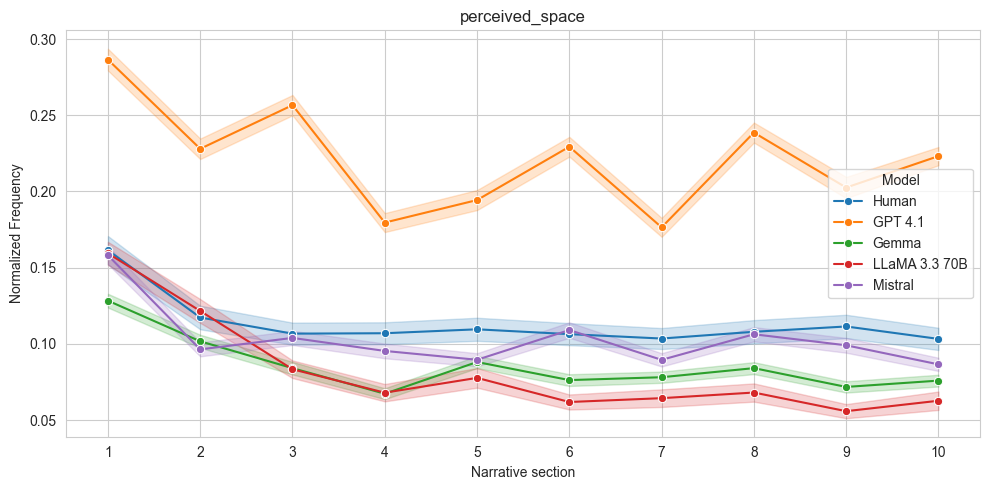

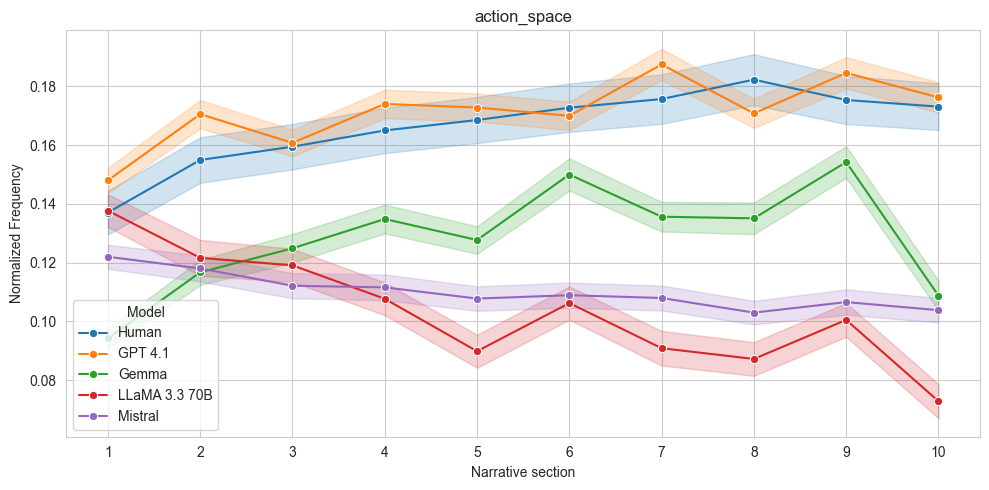

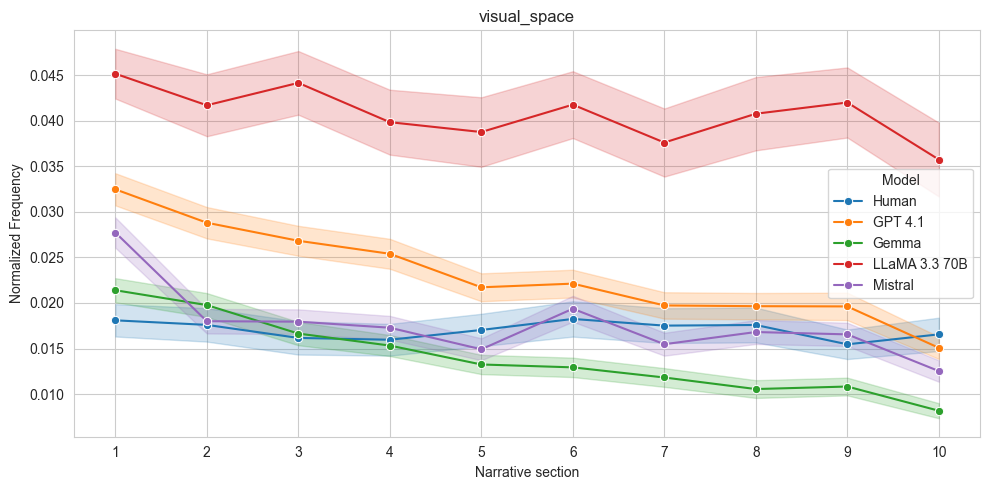

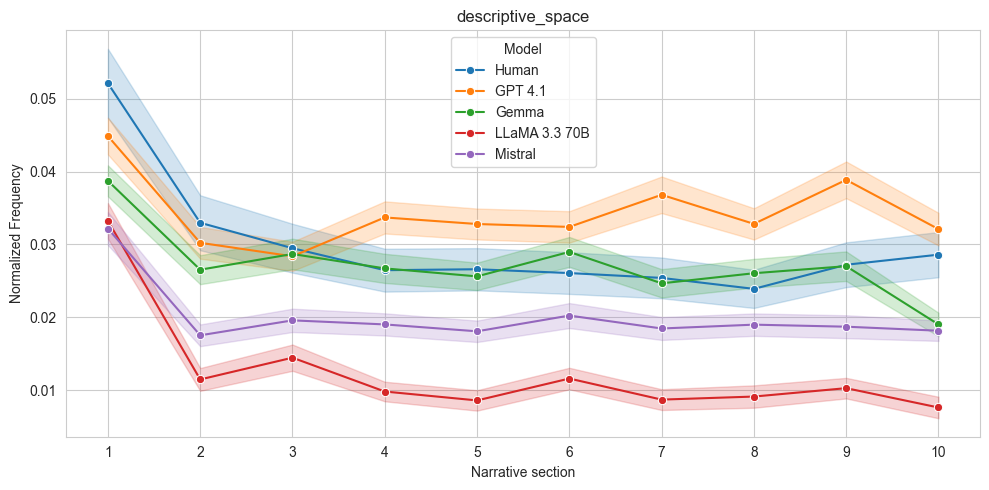

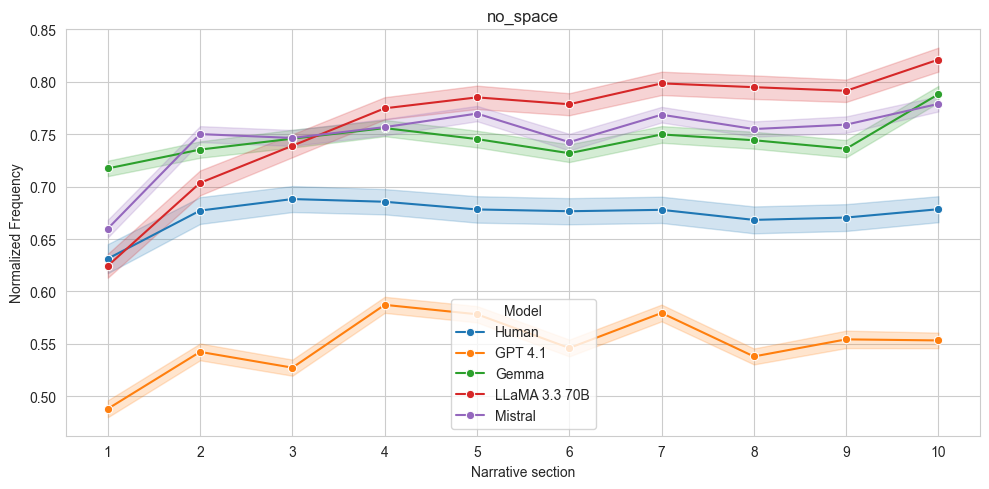

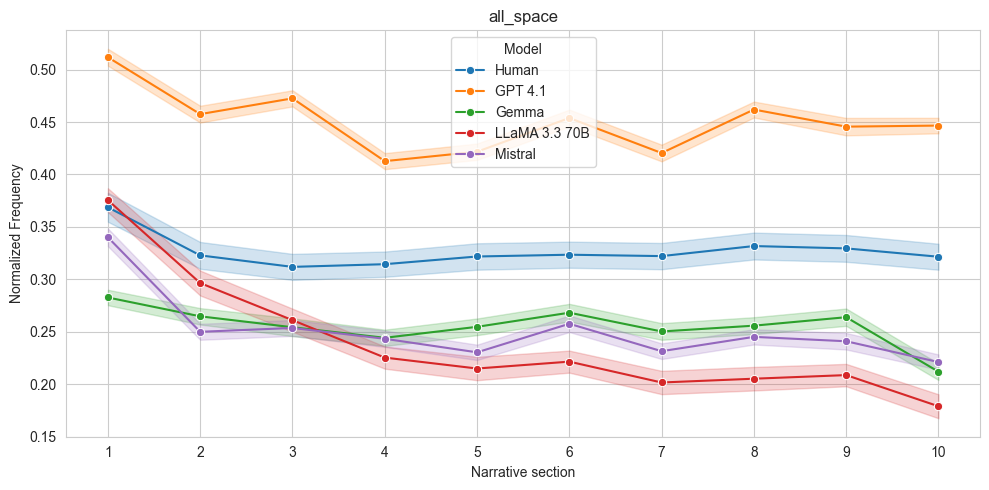

In [25]:
# --- Run everything ---
# adjust num_chunks as suitable for your average text length and test
num_chunks = 10
chunked_result = chunk_and_count_equal(combined_df, num_chunks=num_chunks)
plot_narrative_time_evolution(chunked_result, num_chunks=num_chunks)

,experiment,avg_sentence_length,avg_total_word_count,n_texts
0,GPT 4.1,16.597406,6522.34500,1000
1,Gemma,11.757164,7031.89900,1000
2,Human,27.095804,7596.54251,988
3,LLaMA 3.3 70B,14.572327,6781.36300,1000
4,Mistral,14.393555,7245.43200,1000


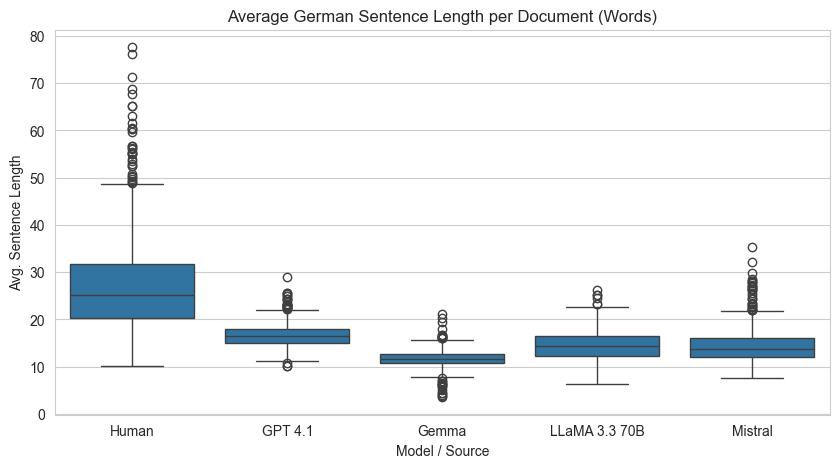

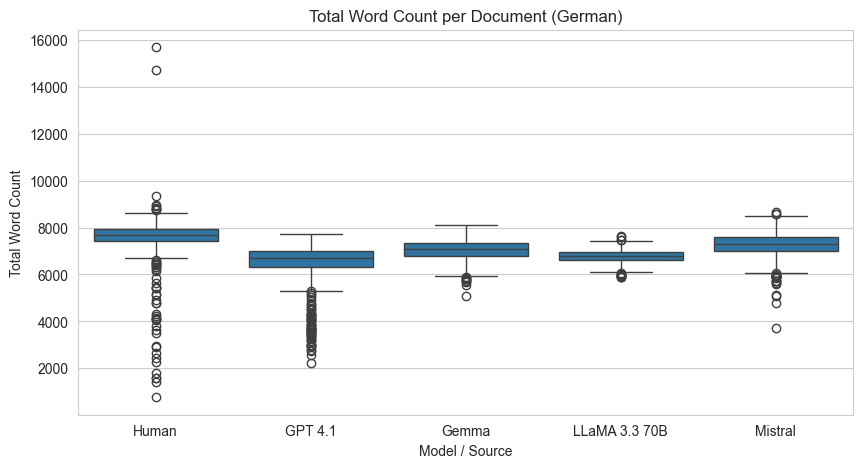

In [33]:
# --- Basic Analysis: Sentence Length and Word Counts ---

# Function to count words in a sentence
def count_words(text):
    return len(str(text).split())

# Add word counts per sentence
combined_df["word_count"] = combined_df["sentence"].apply(count_words)

# Compute average sentence length (in words) per document
avg_sentence_len = (
    combined_df.groupby(["document_id", "experiment"])["word_count"]
    .mean()
    .reset_index(name="avg_sentence_length")
)

# Compute total word count per document
total_word_count = (
    combined_df.groupby(["document_id", "experiment"])["word_count"]
    .sum()
    .reset_index(name="total_word_count")
)

# Merge results
doc_stats = pd.merge(avg_sentence_len, total_word_count, on=["document_id", "experiment"])

# --- Clean up / unify experiment names ---
name_map = {
    "Narrative_Ger_Gemma_3_27B_final": "Gemma",
    "Narrative_Ger_Llama_70B_final": "Llama",
    "Narrative_Ger_Mistral_3.2_24B_final": "Mistral",
    "Narrative_Ger_ChatGPT_Batch_V2": "GPT",
    "Human": "Human"
}

# Replace names, leaving unmapped ones as-is
doc_stats["experiment"] = doc_stats["experiment"].replace(name_map)

# --- Summary across human vs AI models ---
summary_stats = doc_stats.groupby("experiment").agg(
    avg_sentence_length=("avg_sentence_length", "mean"),
    avg_total_word_count=("total_word_count", "mean"),
    n_texts=("document_id", "nunique")
).reset_index()

# --- Display summary ---
display(summary_stats)

# --- Plotting: Average Sentence Length ---
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=doc_stats,
    x="experiment",
    y="avg_sentence_length",
    order=["Human", "GPT 4.1", "Gemma", "LLaMA 3.3 70B", "Mistral"]
)
plt.title("Average German Sentence Length per Document (Words)")
plt.xlabel("Model / Source")
plt.ylabel("Avg. Sentence Length")
plt.show()

# --- Plotting: Total Word Count ---
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=doc_stats,
    x="experiment",
    y="total_word_count",
    order=["Human", "GPT 4.1", "Gemma", "LLaMA 3.3 70B", "Mistral"]
)
plt.title("Total Word Count per Document (German)")
plt.xlabel("Model / Source")
plt.ylabel("Total Word Count")
plt.show()

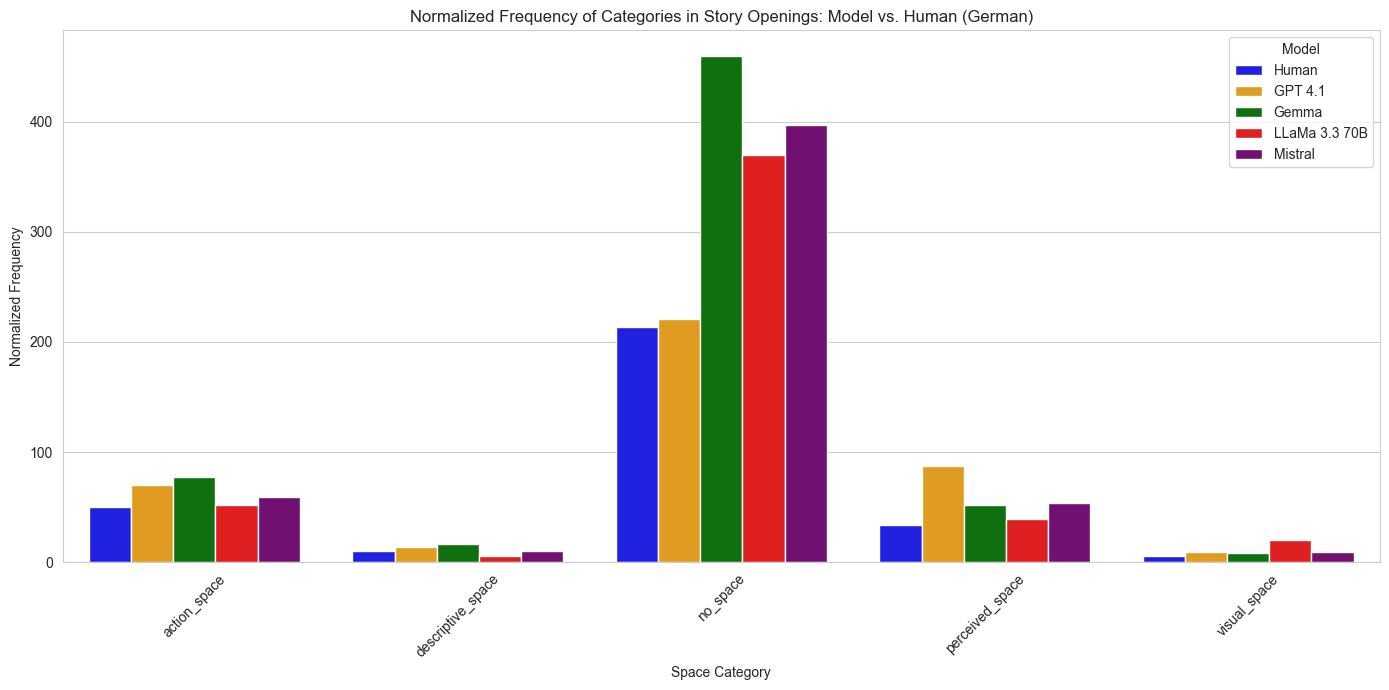

In [34]:
# How frequently the different categories appear at the beginning of human-written stories vs. AI-generated ones. 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

# =====================================================
# Load AI data from parquet
# =====================================================
ai_df = pd.read_parquet("combined_results_Ger.parquet").reset_index()

# Keep only relevant columns
ai_df = ai_df[["document_id", "sentence_id", "label", "experiment"]]
ai_df.rename(columns={"document_id": "filename", "experiment": "model"}, inplace=True)

# Map experiment names to nice model labels
def extract_model_name(exp_name):
    if "Gemma" in exp_name:
        return "Gemma"
    elif "Mistral" in exp_name:
        return "Mistral"
    elif "Llama" in exp_name:
        return "LLaMa 3.3 70B"
    elif "GPT" in exp_name:
        return "GPT 4.1"
    else:
        return exp_name

ai_df["model"] = ai_df["model"].apply(extract_model_name)

# =====================================================
# Load Human data from JSON
# =====================================================
with open("gutenberg_results.json", "r", encoding="utf-8") as f:
    human_data = json.load(f)

human_df = pd.DataFrame([
    {
        "filename": entry["filename"].strip(),
        "sentence_id": i,  # assuming JSON is in narrative order
        "label": entry["prediction"]["label"],
        "model": "Human"
    }
    for i, entry in enumerate(human_data)
])

# =====================================================
# Combine AI + Human
# =====================================================
combined = pd.concat([ai_df, human_df], ignore_index=True)

# Count frequencies per model & label
freqs = (
    combined.groupby(["model", "label"])
    .size()
    .reset_index(name="count")
)

# Normalize by number of documents per model
doc_counts = combined[["filename", "model"]].drop_duplicates().groupby("model").size()
freqs["normalized_count"] = freqs.apply(
    lambda row: row["count"] / doc_counts[row["model"]],
    axis=1
)

# =====================================================
# Visualization with fixed colors and order
# =====================================================
plt.figure(figsize=(14, 7))

# Fixed model order and colors
model_order = ["Human", "GPT 4.1", "Gemma", "LLaMa 3.3 70B", "Mistral"]
model_colors = {
    "Human": "blue",
    "GPT 4.1": "orange",
    "Gemma": "green",
    "LLaMa 3.3 70B": "red",
    "Mistral": "purple"
}

sns.barplot(
    data=freqs,
    x="label",
    y="normalized_count",
    hue="model",
    hue_order=model_order,
    palette=model_colors
)

plt.title("Normalized Frequency of Categories in Story Openings: Model vs. Human (German)")
plt.xlabel("Space Category")
plt.ylabel("Normalized Frequency")
plt.xticks(rotation=45)
plt.legend(title="Model")
plt.tight_layout()
plt.show()


In [14]:
# # Lexical Overlap between adjacent sentences
# # Measure: how many content words in sentence i are reused in sentence i+1, normalized.

# import spacy
# from collections import Counter

# # Load a German NLP model
# nlp = spacy.load("de_core_news_sm")  # or any German model you have

# def content_words(doc):
#     return {token.lemma_.lower() for token in doc if token.is_alpha and not token.is_stop}

# def adjacency_overlap(doc_sentences):
#     overlaps = []
#     for i in range(len(doc_sentences)-1):
#         s1 = nlp(doc_sentences[i])
#         s2 = nlp(doc_sentences[i+1])
#         cw1 = content_words(s1)
#         cw2 = content_words(s2)
#         if len(cw1) == 0 or len(cw2) == 0:
#             overlaps.append(0.0)
#         else:
#             # overlap ratio
#             overlaps.append(len(cw1 & cw2) / len(cw1 | cw2))
#     return sum(overlaps) / len(overlaps) if overlaps else 0.0

# # Apply for each document
# lex_overlap = []
# for (doc_id, experiment), group in combined_df.groupby(["document_id", "experiment"]):
#     # get list of sentences in order
#     sents = group.sort_values("sentence_id")["text"].tolist()
#     score = adjacency_overlap(sents)
#     lex_overlap.append({
#         "document_id": doc_id,
#         "experiment": experiment,
#         "lexical_overlap_adjacent": score
#     })

# lex_overlap_df = pd.DataFrame(lex_overlap)
# display(lex_overlap_df.head())
# # maybe merge with your doc_stats


In [ ]:
# # Semantic Similarity Across Sentences
# # Compute embeddings for each sentence and compute e.g. cosine similarity between adjacent sentences, or between sentence i and midpoint sentence etc., average etc.

# from sentence_transformers import SentenceTransformer
# from sklearn.metrics.pairwise import cosine_similarity
# import numpy as np

# model_emb = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")  # or a German model if available

# sim_scores = []
# for (doc_id, experiment), group in combined_df.groupby(["document_id", "experiment"]):
#     sents = group.sort_values("sentence_id")["text"].tolist()
#     if len(sents) < 2:
#         continue
#     embeddings = model_emb.encode(sents, show_progress_bar=False)
#     sims = [ cosine_similarity([embeddings[i]], [embeddings[i+1]])[0][0] for i in range(len(embeddings)-1) ]
#     avg_sim = float(np.mean(sims))
#     sim_scores.append({
#         "document_id": doc_id,
#         "experiment": experiment,
#         "avg_adjacent_similarity": avg_sim
#     })

# sim_df = pd.DataFrame(sim_scores)
# display(sim_df.head())


In [ ]:
# # Semantic similarity between adjacent sentences
# # If sentence i is always similar in content to i-1, topic drift is low.

# from sentence_transformers import SentenceTransformer
# from sklearn.metrics.pairwise import cosine_similarity
# import numpy as np

# # --- Load multilingual embedding model (works for German + English) ---
# model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

# def compute_adjacent_similarity(sentences):
#     """Average cosine similarity between adjacent sentences."""
#     if len(sentences) < 2:
#         return np.nan
#     embeddings = model.encode(sentences, show_progress_bar=False)
#     sims = cosine_similarity(embeddings[:-1], embeddings[1:])
#     return float(np.mean(np.diag(sims)))

# def compute_chunk_topic_drift(sentences, n_chunks=5):
#     """How often dominant chunk embeddings differ from previous chunk."""
#     if len(sentences) < n_chunks:
#         return np.nan
#     # Split into equal chunks
#     chunks = np.array_split(sentences, n_chunks)
#     chunk_embs = [model.encode([" ".join(chunk)]).flatten() for chunk in chunks]
#     dom_sims = []
#     for i in range(len(chunk_embs)-1):
#         sim = cosine_similarity([chunk_embs[i]], [chunk_embs[i+1]])[0][0]
#         dom_sims.append(sim)
#     # Drift = 1 - similarity, averaged
#     return float(np.mean([1 - s for s in dom_sims]))

# # --- Apply per document ---
# cohesion_results = []
# for (doc_id, experiment), group in combined_df.groupby(["document_id", "experiment"]):
#     sents = group.sort_values("sentence_id")["text"].tolist()
#     adj_sim = compute_adjacent_similarity(sents)
#     chunk_drift = compute_chunk_topic_drift(sents, n_chunks=5)
#     cohesion_results.append({
#         "document_id": doc_id,
#         "experiment": experiment,
#         "avg_adjacent_similarity": adj_sim,
#         "avg_chunk_topic_drift": chunk_drift
#     })

# cohesion_df = pd.DataFrame(cohesion_results)

# # --- Aggregate per experiment ---
# cohesion_summary = cohesion_df.groupby("experiment").agg({
#     "avg_adjacent_similarity": "mean",
#     "avg_chunk_topic_drift": "mean"
# }).reset_index()

# display(cohesion_summary)


In [ ]:
# # Topic modeling + checking consistency of dominant topic
# # For each document, run a topic model (e.g. LDA) to infer topics. Then for each sentence or chunk, find its topic distribution. Compute how much the dominant topic changes between chunks (e.g. variance in topic distributions).
# pip install gensim
# import gensim
# from gensim import corpora
# from gensim.models import LdaModel
# from gensim.parsing.preprocessing import preprocess_string, strip_punctuation, strip_numeric, remove_stopwords
# from gensim.parsing.preprocessing import strip_multiple_whitespaces

# def preprocess(text):
#     filters = [strip_punctuation, strip_numeric, remove_stopwords, strip_multiple_whitespaces]
#     return preprocess_string(text.lower(), filters)

# topic_drift = []
# num_topics = 5  # you can experiment

# # Prepare corpus from all documents or per experiment
# docs = []
# doc_keys = []
# for (doc_id, experiment), group in combined_df.groupby(["document_id", "experiment"]):
#     texts = group.sort_values("sentence_id")["text"].tolist()
#     all_text = " ".join(texts)
#     docs.append(preprocess(all_text))
#     doc_keys.append( (doc_id, experiment) )

# dictionary = corpora.Dictionary(docs)
# corpus = [dictionary.doc2bow(doc) for doc in docs]
# lda = LdaModel(corpus=corpus, id2word=dictionary, num_topics=num_topics, passes=10)

# for i, bow in enumerate(corpus):
#     doc_id, experiment = doc_keys[i]
#     topic_dist = lda.get_document_topics(bow)
#     # get dominant topic
#     dominant = sorted(topic_dist, key=lambda x: -x[1])[0][0]
#     topic_drift.append({
#         "document_id": doc_id,
#         "experiment": experiment,
#         "dominant_topic": dominant
#     })

# topic_drift_df = pd.DataFrame(topic_drift)
# display(topic_drift_df.head())
# # You could also chunk each document, compute dominant topic per chunk, then see how often the dominant topic changes across chunks.


In [ ]:
# import pandas as pd
# from collections import Counter
# import random

# # --- Filter only Llama-generated texts ---
# llama_df = combined_df[combined_df["experiment"].str.contains("Llama")].copy()

# # --- Compute visual space frequency per document ---
# freq_list = []
# for doc_id, group in llama_df.groupby("document_id"):
#     labels = group["label"].tolist()
#     visual_count = labels.count("visual_space")
#     total_count = len(labels)
#     freq = visual_count / total_count
#     freq_list.append({"document_id": doc_id, "frequency": freq})

# freq_df = pd.DataFrame(freq_list)

# # --- Top 5% outlier documents ---
# threshold = freq_df["frequency"].quantile(0.95)
# print(f"Top 5% threshold frequency for visual space: {threshold:.4f}")

# outliers = freq_df[freq_df["frequency"] >= threshold].sort_values("frequency", ascending=False)
# print(f"Number of outlier documents: {len(outliers)}")

# # --- Retrieve sentences for outlier documents ---
# outlier_texts = llama_df[llama_df["document_id"].isin(outliers["document_id"])].copy()

# # Display first 10 sentences of each outlier document
# for doc_id in outliers["document_id"].tolist():
#     print(f"\n=== Document: {doc_id} ===")
#     doc_sentences = outlier_texts[outlier_texts["document_id"] == doc_id][["text", "label"]]
#     display(doc_sentences.head(10))  # first 10 sentences

# # --- Random 3-4 full texts from Llama ---
# random_docs = random.sample(llama_df["document_id"].unique().tolist(), 4)
# print("\n=== Random Full Texts from Llama ===")
# for doc_id in random_docs:
#     print(f"\n--- Document: {doc_id} ---")
#     doc_sentences = llama_df[llama_df["document_id"] == doc_id][["text", "label"]]
#     display(doc_sentences.head(10))  # first 10 sentences

# # --- Save outlier documents to CSV in current directory ---
# outlier_texts.to_csv("llama_visual_space_outliers.csv", index=False)
# print(f"Saved {len(outlier_texts)} outlier sentences to 'llama_visual_space_outliers.csv'.") 
# # Contains all the sentences from the top 5% documents with the highest visual space frequency.

# # --- Save random full texts to CSV in current directory ---
# random_texts_list = []
# for doc_id in random_docs:
#     doc_sentences = llama_df[llama_df["document_id"] == doc_id].copy()
#     doc_sentences["random_doc"] = doc_id  # tag each row with document ID
#     random_texts_list.append(doc_sentences)

# random_texts_df = pd.concat(random_texts_list, ignore_index=True)
# random_texts_df.to_csv("llama_random_texts.csv", index=False)
# print(f"Saved {len(random_texts_df)} sentences from 4 random documents to 'llama_random_texts.csv'.")
# # Contains sentences from 4 randomly chosen Llama-generated documents, regardless of visual space frequency.
